In [2]:
import pandas as pd
import os
from pathlib import Path

# 1. Configuración de rutas
# Estamos en src/modelos/problema4/
# Subimos 3 niveles para llegar a la raíz y bajar a data/processed/...
BASE_DIR = Path(os.getcwd()).resolve().parents[2]
DATA_P4_DIR = os.path.join(BASE_DIR, 'data', 'processed', 'tlc_clean', 'problema4')

archivos = {
    "Entrenamiento (Train)": "train_p4.parquet",
    "Validación (Val)": "val_p4.parquet",
    "Prueba (Test)": "test_p4.parquet"
}

print(f"Buscando archivos en: {DATA_P4_DIR}\n")

# 2. Comprobación de dimensiones y carga
resumen = []

for nombre, archivo in archivos.items():
    ruta_completa = os.path.join(DATA_P4_DIR, archivo)
    
    if os.path.exists(ruta_completa):
        # Cargamos solo el encabezado para la vista rápida
        df_temp = pd.read_parquet(ruta_completa)
        
        # Guardamos info para el resumen
        resumen.append({
            "Dataset": nombre,
            "Filas": f"{len(df_temp):,}",
            "Columnas": len(df_temp.columns),
            "Tamaño (MB)": round(os.path.getsize(ruta_completa) / (1024 * 1024), 2),
            "Meses": df_temp['mes_num'].unique().tolist()
        })
        
        print(f"--- {nombre.upper()} ---")
        display(df_temp.head(3))
        print("-" * 50)
    else:
        print(f"❌ Error: No se encontró el archivo {archivo}")

# 3. Mostrar tabla resumen de los conjuntos de datos
print("\nRESUMEN DE LOS DATASETS GENERADOS:")
df_resumen = pd.DataFrame(resumen)
display(df_resumen)

Buscando archivos en: C:\Users\PC\Desktop\3ºGIDIA\PD2\PD2-conducIA\data\processed\tlc_clean\problema4

--- ENTRENAMIENTO (TRAIN) ---


,fecha_inicio,origen_id,destino_id,velocidad_mph,temp_c,precipitation,viento_kmh,lluvia,nieve,es_festivo,num_eventos,mes_num,dia_semana,es_fin_semana,hora_sen,hora_cos,tipo_vehiculo,franja_horaria,hay_lluvia,hay_nieve
0,2024-12-01,144,113,9.046154,-2.0,0.0,10.3,0,0,0,0,12,6,1,0.0,1.0,Yellow Taxi,Madrugada,0,0
1,2024-12-01,71,71,11.954286,-1.8,0.0,10.9,0,0,0,0,12,6,1,0.0,1.0,VTC,Madrugada,0,0
2,2024-12-01,36,37,7.965065,-1.8,0.0,10.9,0,0,0,0,12,6,1,0.0,1.0,VTC,Madrugada,0,0


--------------------------------------------------
--- VALIDACIÓN (VAL) ---


,fecha_inicio,origen_id,destino_id,velocidad_mph,temp_c,precipitation,viento_kmh,lluvia,nieve,es_festivo,num_eventos,mes_num,dia_semana,es_fin_semana,hora_sen,hora_cos,tipo_vehiculo,franja_horaria,hay_lluvia,hay_nieve
0,2025-09-01,85,39,11.985472,19.4,0.0,1.4,0,0,1,1,9,0,0,0.0,1.0,VTC,Madrugada,0,0
1,2025-09-01,142,233,9.359223,19.1,0.0,0.5,0,0,1,1,9,0,0,0.0,1.0,VTC,Madrugada,0,0
2,2025-09-01,35,189,12.099586,19.4,0.0,1.4,0,0,1,1,9,0,0,0.0,1.0,VTC,Madrugada,0,0


--------------------------------------------------
--- PRUEBA (TEST) ---


,fecha_inicio,origen_id,destino_id,velocidad_mph,temp_c,precipitation,viento_kmh,lluvia,nieve,es_festivo,num_eventos,mes_num,dia_semana,es_fin_semana,hora_sen,hora_cos,tipo_vehiculo,franja_horaria,hay_lluvia,hay_nieve
0,2025-10-01,236,140,11.780105,17.000000,0.0,14.2,0,0,0,3,10,2,0,0.0,1.0,VTC,Madrugada,0,0
1,2025-10-01,132,219,21.805368,18.200001,0.0,13.9,0,0,0,3,10,2,0,0.0,1.0,VTC,Madrugada,0,0
2,2025-10-01,132,155,32.196850,18.200001,0.0,13.9,0,0,0,3,10,2,0,0.0,1.0,VTC,Madrugada,0,0


--------------------------------------------------

RESUMEN DE LOS DATASETS GENERADOS:


,Dataset,Filas,Columnas,Tamaño (MB),Meses
0,Entrenamiento (Train),"60,045,942",20,625.90,"[12, 1, 2, 3, 4, 5, 6, 7, 8]"
1,Validación (Val),"6,463,022",20,68.18,[9]
2,Prueba (Test),"13,932,337",20,145.26,"[10, 11]"


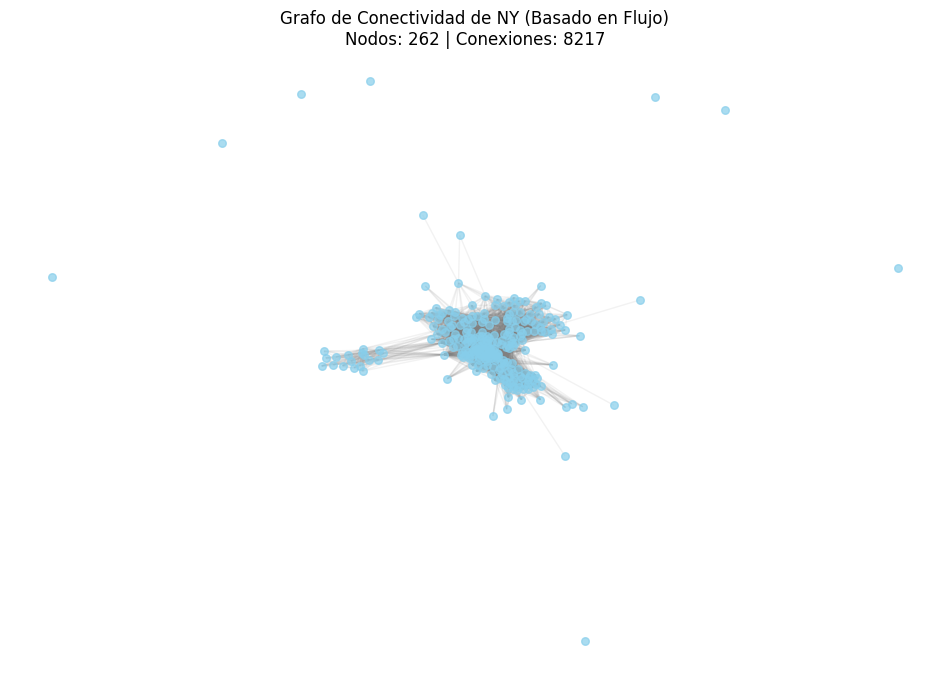

Conexiones totales: 8217
Media de vecinos por zona: 62.73
Zona con más conexiones: Nodo 130 con 221 vecinos.


In [3]:
#codigo para visualizar el grafo
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
from pathlib import Path

# 1. Rutas
BASE_DIR = Path(os.getcwd()).resolve().parents[2]
DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed', 'tlc_clean', 'problema4')

# 2. Cargar la matriz que acabas de generar
adj_matrix = np.load(os.path.join(DATA_DIR, 'adj_matrix.npy'))

# 3. Crear el objeto Grafo desde la matriz
# Quitamos la diagonal (auto-conexiones) para que el dibujo sea más limpio
adj_temp = adj_matrix.copy()
np.fill_diagonal(adj_temp, 0)
G = nx.from_numpy_array(adj_temp)

# 4. Visualización
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.15, seed=42) # Algoritmo de fuerzas para separar nodos

nx.draw_networkx_nodes(G, pos, node_size=30, node_color='skyblue', alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')

plt.title(f"Grafo de Conectividad de NY (Basado en Flujo)\nNodos: {G.number_of_nodes()} | Conexiones: {G.number_of_edges()}")
plt.axis('off')
plt.show()

# 5. Estadísticas rápidas
print(f"Conexiones totales: {G.number_of_edges()}")
grados = [val for (node, val) in G.degree()]
print(f"Media de vecinos por zona: {np.mean(grados):.2f}")
print(f"Zona con más conexiones: Nodo {np.argmax(grados)} con {np.max(grados)} vecinos.")

In [10]:
import numpy as np
import json
import os
from pathlib import Path

# 1. Rutas
BASE_DIR = Path(os.getcwd()).resolve().parents[2]
DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed', 'tlc_clean', 'problema4')

# 2. Diccionario de referencia rápido (Nombres reales de NY para los IDs)
# Estos son los barrios más comunes en el dataset
nombres_zonas = {
    132: "JFK Airport (Queens)",
    138: "LaGuardia Airport (Queens)",
    161: "Midtown Center (Manhattan)",
    162: "Midtown East (Manhattan)",
    236: "Upper East Side North (Manhattan)",
    237: "Upper East Side South (Manhattan)",
    7: "Astoria (Queens)",
    170: "Murray Hill (Manhattan)",
    107: "Gramercy (Manhattan)",
    48: "Clinton East (Manhattan)",
    230: "Times Square/Theatre District",
    142: "Lincoln Square East (Manhattan)"
}

# 3. Carga de datos del grafo
adj_matrix = np.load(os.path.join(DATA_DIR, 'adj_matrix.npy'))
with open(os.path.join(DATA_DIR, 'mapa_nodos.json'), 'r') as f:
    mapa_ids = json.load(f)

idx_to_id = {int(v): int(k) for k, v in mapa_ids.items()}

def obtener_nombre(id_zona):
    return nombres_zonas.get(int(id_zona), f"Zona ID {id_zona} (Barrio periférico)")

print("--- EXAMINANDO CONEXIONES REALES DEL GRAFO ---\n")

# Vamos a elegir 3 zonas clave y ver con quién las ha "pegado" el algoritmo
zonas_interes = [132, 237, 7] # JFK, Upper East Side, Astoria

for id_buscado in zonas_interes:
    nombre_principal = obtener_nombre(id_buscado)
    idx = mapa_ids[str(id_buscado)]
    
    # Encontrar vecinos en la matriz
    fila = adj_matrix[idx]
    indices_vecinos = np.where(fila == 1)[0]
    
    # Traducir y filtrar (quitarse a sí mismo)
    vecinos_ids = [idx_to_id[i] for i in indices_vecinos if idx_to_id[i] != id_buscado]
    
    print(f"📍 {nombre_principal} está conectada con {len(vecinos_ids)} zonas.")
    print(f"   Algunas conexiones detectadas por flujo de taxis:")
    
    # Mostrar los primeros 5 vecinos con nombre
    for v_id in vecinos_ids[:6]:
        print(f"    - -> {obtener_nombre(v_id)}")
    print("    - ... y muchas más.\n")

--- EXAMINANDO CONEXIONES REALES DEL GRAFO ---

📍 JFK Airport (Queens) está conectada con 221 zonas.
   Algunas conexiones detectadas por flujo de taxis:
    - -> Zona ID 1 (Barrio periférico)
    - -> Zona ID 3 (Barrio periférico)
    - -> Zona ID 4 (Barrio periférico)
    - -> Astoria (Queens)
    - -> Zona ID 9 (Barrio periférico)
    - -> Zona ID 10 (Barrio periférico)
    - ... y muchas más.

📍 Upper East Side South (Manhattan) está conectada con 109 zonas.
   Algunas conexiones detectadas por flujo de taxis:
    - -> Zona ID 1 (Barrio periférico)
    - -> Zona ID 4 (Barrio periférico)
    - -> Astoria (Queens)
    - -> Zona ID 13 (Barrio periférico)
    - -> Zona ID 14 (Barrio periférico)
    - -> Zona ID 17 (Barrio periférico)
    - ... y muchas más.

📍 Astoria (Queens) está conectada con 153 zonas.
   Algunas conexiones detectadas por flujo de taxis:
    - -> Zona ID 1 (Barrio periférico)
    - -> Zona ID 4 (Barrio periférico)
    - -> Zona ID 8 (Barrio periférico)
    - -> Zon